<a href="https://colab.research.google.com/github/ladybug-tentoumushi/Fashion_MNIST/blob/main/fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration
Let us load the libraries we are giong to use in our notebook and also dataset to display it and get grasp of the data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
work_dir = 'drive/MyDrive/DLBasics2026_colab'

In [ ]:
import torch
import numpy as np
import torch.optim as optim
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
seed = 1234
torch.manual_seed(seed)
np.random.seed(seed)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
x_train = np.load(work_dir + '/Lecture 2/data/x_train.npy')
t_train = np.load(work_dir + '/Lecture 2/data/y_train.npy')
x_test = np.load(work_dir + '/Lecture 2/data/x_test.npy')

class train_dataset(torch.utils.data.Dataset):
    def __init__(self, x_train, t_train):
        self.x_train = x_train.reshape(-1, 784).astype('float32') / 255
        self.t_train = t_train

    def __len__(self):
        return self.x_train.shape[0]

    def __getitem__(self, idx):
        return torch.tensor(self.x_train[idx], dtype=torch.float), torch.tensor(self.t_train[idx], dtype=torch.long)

class test_dataset(torch.utils.data.Dataset):
    def __init__(self, x_test):
        self.x_test = x_test.reshape(-1, 784).astype('float32') / 255

    def __len__(self):
        return self.x_test.shape[0]

    def __getitem__(self, idx):
        return torch.tensor(self.x_test[idx], dtype=torch.float)

trainval_data = train_dataset(x_train, t_train)
test_data = test_dataset(x_test)

In [ ]:
batch_size = 32

val_size = 10000
train_size = len(trainval_data) - val_size

train_data, val_data = torch.utils.data.random_split(trainval_data, [train_size, val_size])

dataloader_train = torch.utils.data.DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

dataloader_valid = torch.utils.data.DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

dataloader_test = torch.utils.data.DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
def relu(x):
    x = torch.where(x > 0, x, torch.zeros_like(x))
    return x

def softmax(x):
    x -= torch.cat([x.max(axis=1, keepdim=True).values] * x.size()[1], dim=1)
    x_exp = torch.exp(x)
    return x_exp/torch.cat([x_exp.sum(dim=1, keepdim=True)] * x.size()[1], dim=1)

In [ ]:
class Dense(nn.Module):
  def __init__(self, in_dim, out_dim, function=lambda x: x):
    super().__init__()
    limit = np.sqrt(6 / in_dim) # Heの一様分布
    self.W = nn.Parameter(  # nn.Parameterを使うことでWをパラメータとして渡すことができる
        torch.tensor(np.random.uniform(
            low = -limit, high = limit, size = (in_dim, out_dim)), dtype=torch.float32)
    )
    self.b = nn.Parameter(torch.tensor(np.zeros([out_dim]).astype('float32')))
    self.function = function

  def forward(self, x):
    return self.function(torch.matmul(x, self.W)+ self.b)

In [ ]:
class MLP(nn.Module):
  def __init__(self, in_dim, hid_dim, out_dim):
    super().__init__()
    self.liner1 = Dense(in_dim, hid_dim, function=relu)
    self.liner2 = Dense(hid_dim, out_dim, function=softmax)

  def forward(self, x):
    x = self.liner1(x)
    x = self.liner2(x)
    return(x)

In [ ]:
in_dim = 784
hid_dim = 200
out_dim = 10
lr = 0.001
batch_size = 32
n_epochs = 10


mlp = MLP(in_dim, hid_dim, out_dim).to(device)

optimizer = optim.SGD(mlp.parameters(), lr=lr)

In [ ]:
# history_1: make list
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

# confusion_matrix_1: make list
t_true = []
t_pred_cm = []

for epoch in range(n_epochs):
    losses_train = []
    losses_valid = []
    train_num = 0
    train_true_num = 0
    valid_num = 0
    valid_true_num = 0

    mlp.train()  # Training mode (compute gradients) ← nn.Module　method Dropout, Batch Norm is active
    for x, t in dataloader_train:
        # convert labels to one-hot vectors
        t_hot = torch.eye(10)[t]

        # move tensors to GPU
        x = x.to(device)
        t_hot = t_hot.to(device)

        # forward
        y = mlp(x)

        # compute loss
        loss = -(t_hot * torch.log(y + 1e-8)).sum(axis=1).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pred = torch.argmax(y, dim=1)
        true = torch.argmax(t_hot, dim=1)

        losses_train.append(loss.tolist())

        acc = torch.where(t - pred.to("cpu") == 0, torch.ones_like(t), torch.zeros_like(t))
        train_num += acc.size()[0]
        train_true_num += acc.sum().item()
        # confusion_matrix_3: extend list
        t_true.extend(t.tolist())
        t_pred_cm.extend(pred.tolist())

    mlp.eval()  # Eval mode (do not compute gradients)
    for x, t in dataloader_valid:
        t_hot = torch.eye(10)[t]

        x = x.to(device)

        y = mlp(x)

        loss = -(t_hot * torch.log(y + 1e-8)).sum(axis=1).mean()

        pred = torch.argmax(y, dim=1)

        losses_valid.append(loss.tolist())

        acc = torch.where(t - pred.to("cpu") == 0, torch.ones_like(t), torch.zeros_like(t))
        valid_num += acc.size()[0]
        valid_true_num += acc.sum().item()

    # history_2: calcurate every epoch mean
    train_loss = np.mean(losses_train)
    train_acc = train_true_num / train_num
    valid_loss = np.mean(losses_valid)
    valid_acc = valid_true_num / valid_num

    # history_3: save dict
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(valid_loss)
    history['val_accuracy'].append(valid_acc)

    print('EPOCH: {}, Train [Loss: {:.3f}, Accuracy: {:.3f}], Valid [Loss: {:.3f}, Accuracy: {:.3f}]'.format(
        epoch,
        np.mean(losses_train),
        train_true_num/train_num,
        np.mean(losses_valid),
        valid_true_num/valid_num
    ))

EPOCH: 0, Train [Loss: 1.433, Accuracy: 0.573], Valid [Loss: 1.016, Accuracy: 0.702]
EPOCH: 1, Train [Loss: 0.907, Accuracy: 0.720], Valid [Loss: 0.816, Accuracy: 0.743]
EPOCH: 2, Train [Loss: 0.777, Accuracy: 0.754], Valid [Loss: 0.729, Accuracy: 0.769]
EPOCH: 3, Train [Loss: 0.710, Accuracy: 0.773], Valid [Loss: 0.680, Accuracy: 0.779]
EPOCH: 4, Train [Loss: 0.666, Accuracy: 0.785], Valid [Loss: 0.640, Accuracy: 0.790]
EPOCH: 5, Train [Loss: 0.634, Accuracy: 0.795], Valid [Loss: 0.613, Accuracy: 0.800]
EPOCH: 6, Train [Loss: 0.610, Accuracy: 0.801], Valid [Loss: 0.593, Accuracy: 0.809]
EPOCH: 7, Train [Loss: 0.590, Accuracy: 0.808], Valid [Loss: 0.576, Accuracy: 0.808]
EPOCH: 8, Train [Loss: 0.574, Accuracy: 0.811], Valid [Loss: 0.561, Accuracy: 0.816]
EPOCH: 9, Train [Loss: 0.560, Accuracy: 0.815], Valid [Loss: 0.549, Accuracy: 0.818]


In [ ]:
mlp.eval()

t_pred = []
for x in dataloader_test:

    x = x.to(device)

    # Forward propagation
    y = mlp.forward(x)

    # Convert the model output to scalar class predictions
    pred = y.argmax(1).tolist()

    t_pred.extend(pred)

submission = pd.Series(t_pred, name='label')
submission.to_csv(work_dir + '/Lecture04/submission_pred_04.csv', header=True, index_label='id')

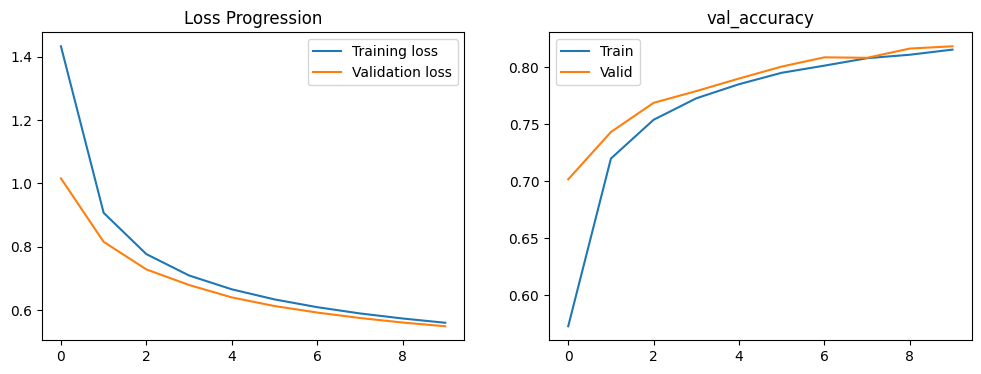

In [ ]:
#1行2列でグラフを並べる例
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 左側にLoss
ax[0].plot(history['loss'], label='Training loss')
ax[0].plot(history['val_loss'], label='Validation loss')
ax[0].set_title("Loss Progression")
ax[0].legend()

# 右側にAccuracy
ax[1].plot(history['accuracy'], label="Train")
ax[1].plot(history['val_accuracy'], label="Valid")
ax[1].set_title("val_accuracy")
ax[1].legend()

plt.show()

In [ ]:
class_name = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 混合行列表示
cm = confusion_matrix(t_true, t_pred_cm)
# cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in class_name], columns=[f"pred_{c}" for c in class_name])
cm_df = pd.DataFrame(cm, index=[["true"]*len(class_name), class_name], columns=[["pred"]*len(class_name), class_name])
# 合計追加
cm_df[("pred", "合計")] = cm_df.sum(axis=1)
cm_df.loc[("true", "合計"), :] = cm_df.sum(axis=0)
cm_df= cm_df.astype(int)
# 表示
display(cm_df.style.background_gradient(cmap="Blues", subset=pd.IndexSlice[cm_df.index[:-1], cm_df.columns[:-1]]))

In [ ]:
class_names = ["Class 0 => T-shirt",
               "Class 1 => Trouser",
               "Class 2 => Pullover",
               "Class 3 => Dress",
               "Class 4 => Coat",
               "Class 5 => Sandal",
               "Class 6 => Shirt",
               "Class 7 => Sneaker",
               "Class 8 => Bag",
               "Class 9 => Ankle boot"]
print(classification_report(t_true, t_pred_cm, target_names=class_names))

                       precision    recall  f1-score   support

   Class 0 => T-shirt       0.73      0.79      0.76     49870
   Class 1 => Trouser       0.93      0.93      0.93     50050
  Class 2 => Pullover       0.65      0.63      0.64     50500
     Class 3 => Dress       0.76      0.83      0.80     50330
      Class 4 => Coat       0.58      0.73      0.65     50390
    Class 5 => Sandal       0.93      0.70      0.80     50280
     Class 6 => Shirt       0.55      0.35      0.43     49820
   Class 7 => Sneaker       0.78      0.86      0.82     49480
       Class 8 => Bag       0.89      0.90      0.89     49180
Class 9 => Ankle boot       0.82      0.92      0.86     50100

             accuracy                           0.76    500000
            macro avg       0.76      0.76      0.76    500000
         weighted avg       0.76      0.76      0.76    500000



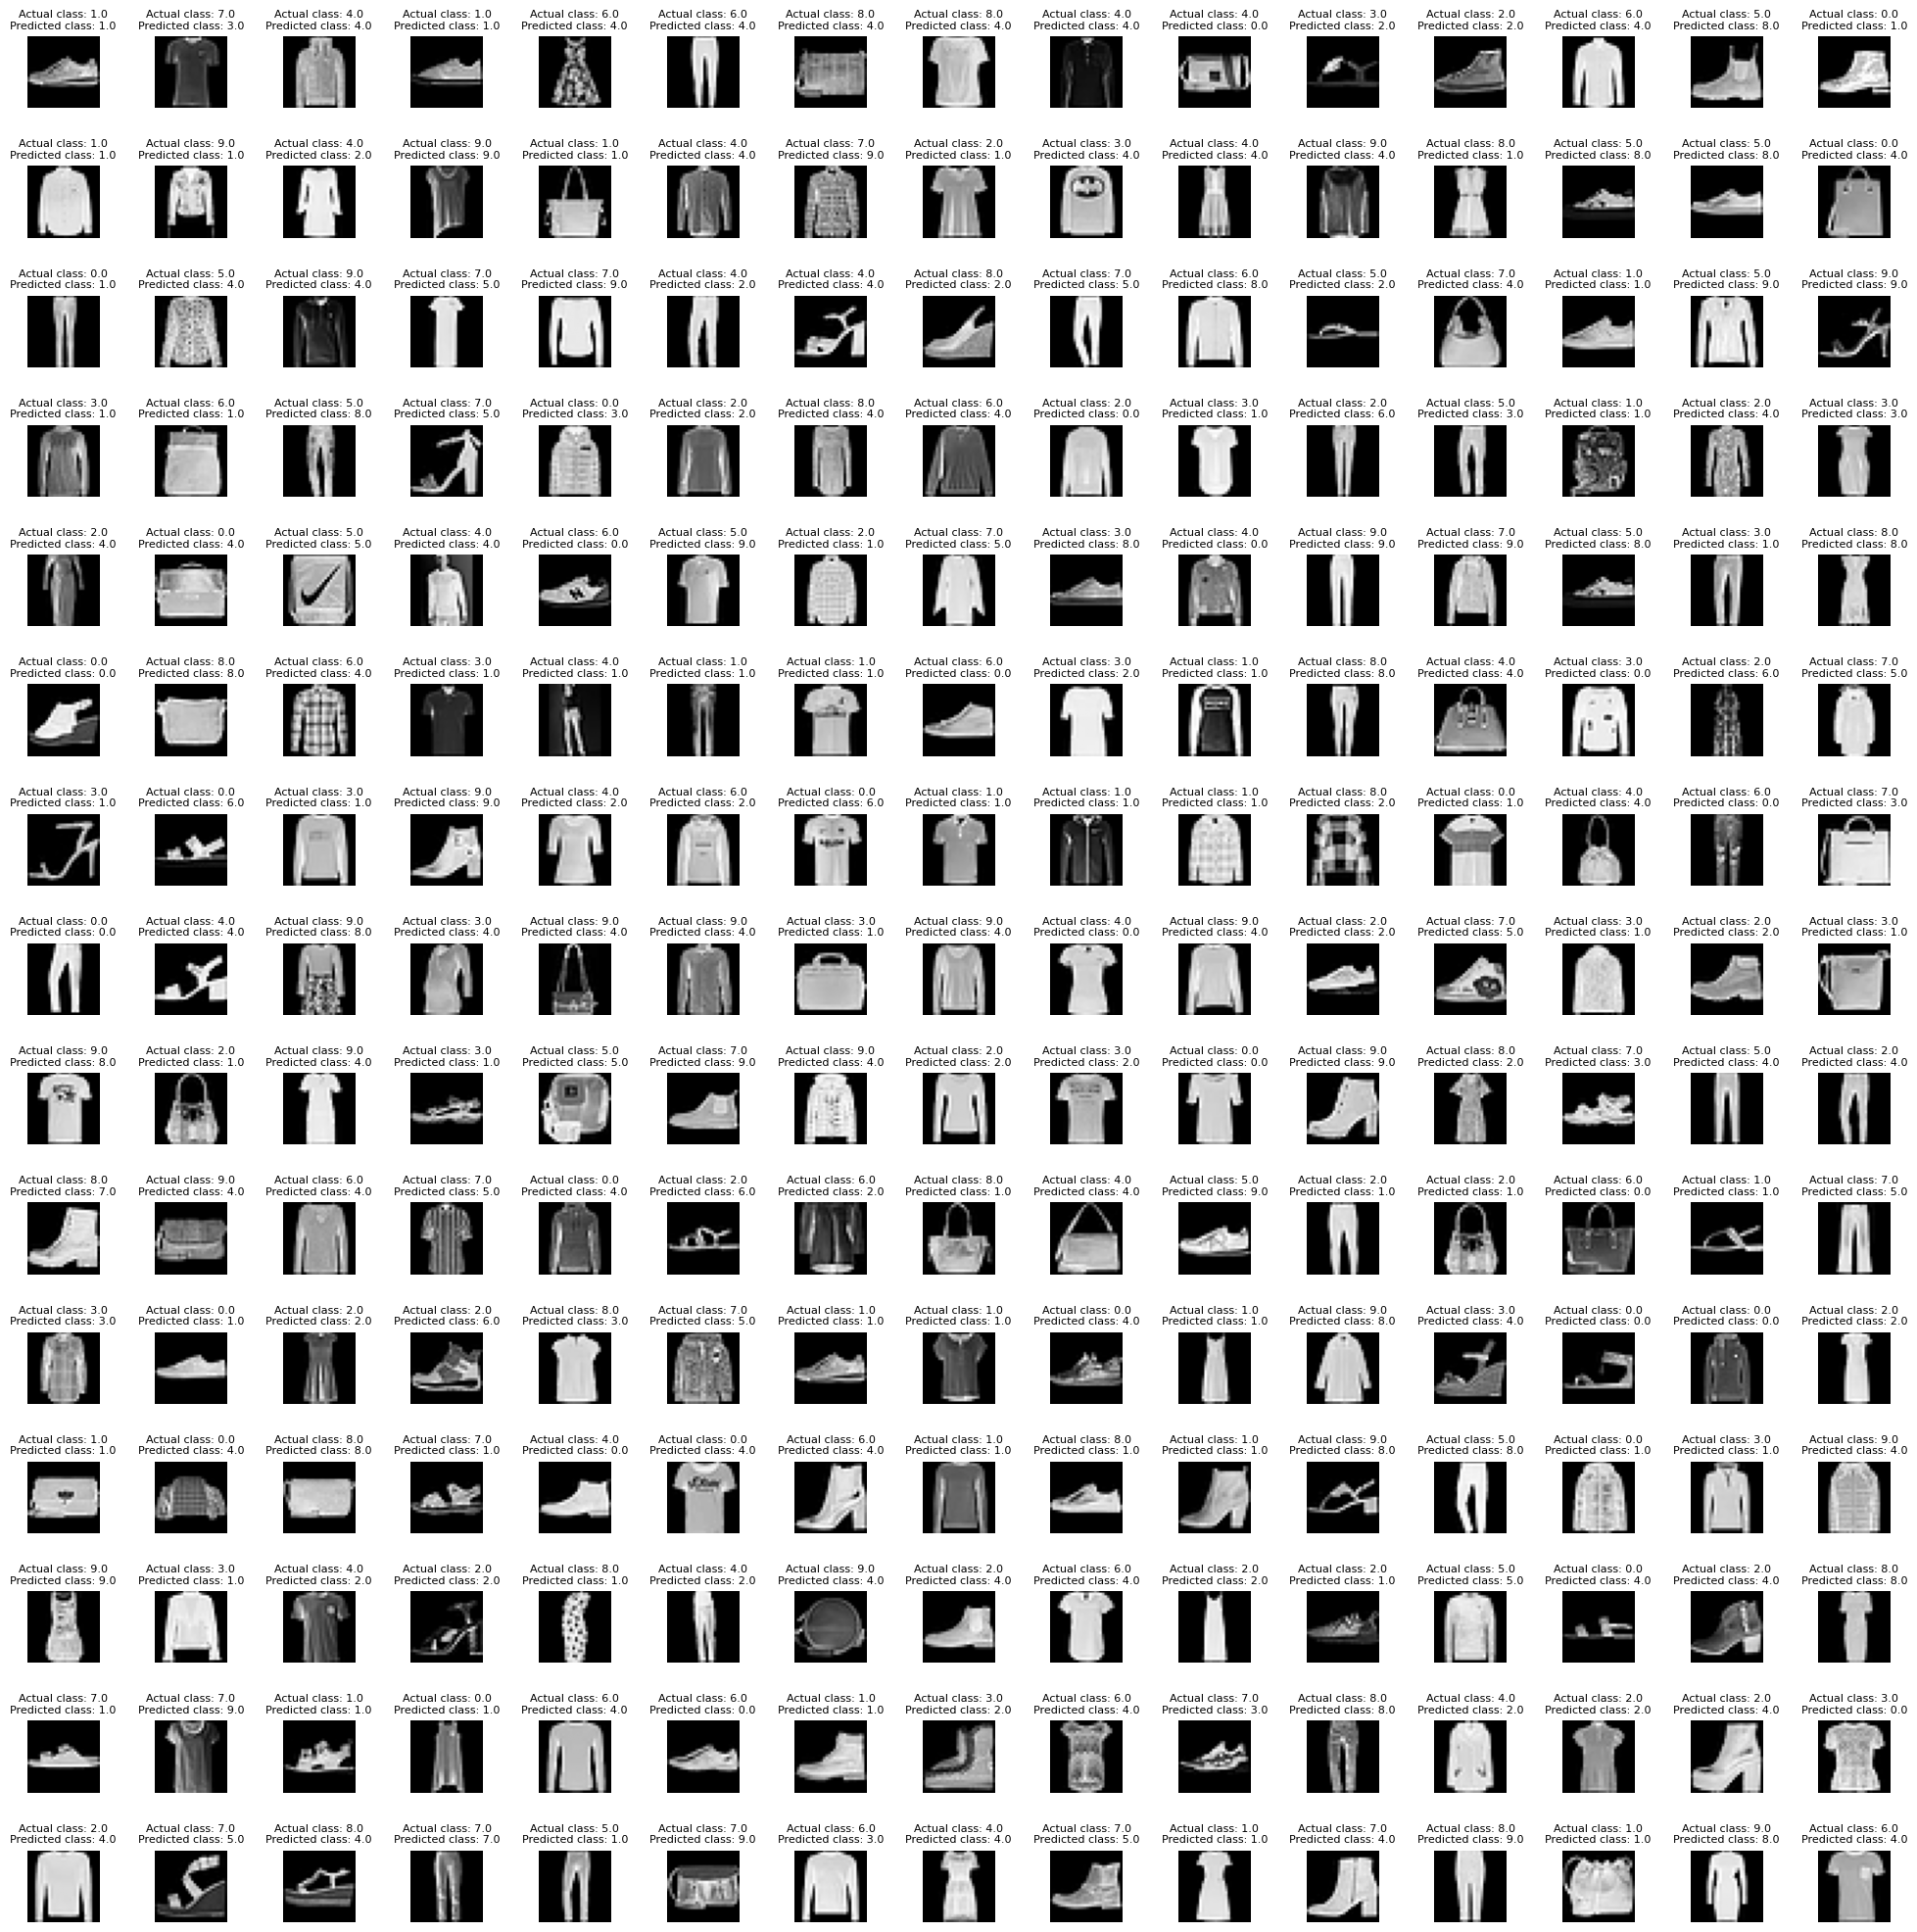

In [ ]:
# Grid dimensions.
grid_height = 15
grid_width = 15

fig, axes = plt.subplots(grid_height, grid_width, figsize=(25, 25))
axes = axes.ravel()

for i in range(grid_height * grid_width):
    # Draft random index to plot random image.
    drafted_image = np.random.randint(0, x_test.shape[0])
    axes[i].imshow(x_test[drafted_image].reshape(28, 28), cmap='gray')
    # Print actual and predicted labels for image.
    axes[i].set_title("Actual class: {:0.1f}\nPredicted class: {:0.1f}".format(
        t_true[drafted_image], t_pred_cm[drafted_image]), fontsize=8)
    axes[i].axis('off')
plt.subplots_adjust(hspace=0.8)